# 08 Single-Claim Inference Demo

This notebook loads the best-performing fine-tuned transformer model identified in `07_model_comparison_three_way.ipynb` and classifies a user-supplied health claim in real time, returning a **label** (`Reliable` / `Misinformation`) and a **confidence score**.

**Use cases:**
- Interactively test the model on new claims during development.
- Run batch inference on a custom list of claims.
- Demonstrate the system as part of a thesis defence or presentation.

**No re-training required** — the saved model weights from notebook 06 (or 04) are loaded directly.


## 1. Imports


In [13]:
from pathlib import Path
import json
import textwrap

import joblib
import numpy as np
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification


## 2. Paths and Device


In [14]:
PROJECT_ROOT = Path(r"C:\Users\ribam\Desktop\Reseach\Dataset")
OUTPUT_ROOT = PROJECT_ROOT / "output"
MODEL_ROOT = PROJECT_ROOT / "model"

MODEL_DIR_MAP = {
    "BioBERT": MODEL_ROOT / "biobert_fakehealth_healthfact",
    "PubMedBERT": MODEL_ROOT / "pubmedbert_fakehealth_healthfact",
}

TFIDF_MODEL_CANDIDATES = [
    MODEL_ROOT / "tfidf_logreg.joblib",
    MODEL_ROOT / "tfidf_logreg_fakehealth_healthfact.joblib",
]

ID2LABEL = {0: "misinformation", 1: "reliable"}
LABEL2ID = {"misinformation": 0, "reliable": 1}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


Device: cpu


## 3. Auto-Select the Best Model

Reads the `comparison_summary.json` written by notebook 07 and picks whichever transformer scored the highest test F1. If the summary file is not yet available (e.g. notebook 07 has not been run), the fallback can be set manually below.


In [15]:
SUMMARY_PATH = OUTPUT_ROOT / "model_comparison_three_way" / "comparison_summary.json"
FALLBACK_TRANSFORMER = "BioBERT"
DECISION_RULE = "TF-IDF + Logistic Regression"

if SUMMARY_PATH.exists():
    summary = json.loads(SUMMARY_PATH.read_text(encoding="utf-8"))
    DECISION_RULE = summary.get("recommended_decision_rule", DECISION_RULE)
    transformer_scores = {
        model_name: score
        for model_name, score in summary.get("macro_f1_scores", summary.get("test_f1_scores", {})).items()
        if model_name in MODEL_DIR_MAP
    }
    best_transformer_name = max(transformer_scores, key=transformer_scores.get) if transformer_scores else FALLBACK_TRANSFORMER
    print("Decision rule from summary:", DECISION_RULE)
    print("Transformer scores:", transformer_scores)
else:
    summary = {}
    best_transformer_name = FALLBACK_TRANSFORMER
    print("Summary file not found; using fallback transformer:", best_transformer_name)

print("Best transformer for single-model fallback:", best_transformer_name)


Decision rule from summary: Majority Vote
Transformer scores: {'BioBERT': 0.74606, 'PubMedBERT': 0.733072}
Best transformer for single-model fallback: BioBERT


## 4. Load Tokenizer and Model


In [16]:
def load_tfidf_pipeline():
    for path in TFIDF_MODEL_CANDIDATES:
        if path.exists():
            print("Loaded TF-IDF pipeline from:", path)
            return joblib.load(path)
    print("TF-IDF pipeline not found.")
    return None


def load_transformer_bundle(model_name):
    model_dir = MODEL_DIR_MAP[model_name]
    if not model_dir.exists():
        print(f"{model_name} directory not found:", model_dir)
        return None
    tokenizer = AutoTokenizer.from_pretrained(str(model_dir), use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(str(model_dir))
    model.to(DEVICE)
    model.eval()
    id2label = {int(k): v for k, v in model.config.id2label.items()}
    return {"tokenizer": tokenizer, "model": model, "id2label": id2label}


tfidf_pipeline = load_tfidf_pipeline()
transformer_bundles = {
    model_name: bundle
    for model_name in MODEL_DIR_MAP
    if (bundle := load_transformer_bundle(model_name)) is not None
}

print("Available transformers:", list(transformer_bundles))


Loaded TF-IDF pipeline from: C:\Users\ribam\Desktop\Reseach\Dataset\model\tfidf_logreg.joblib
Available transformers: ['BioBERT', 'PubMedBERT']


## 5. Inference Helper Functions


In [17]:
MAX_LENGTH = 256


def predict_tfidf(text: str) -> dict | None:
    if tfidf_pipeline is None:
        return None
    probs = tfidf_pipeline.predict_proba([text])[0]
    label_id = int(np.argmax(probs))
    return {
        "model": "TF-IDF + Logistic Regression",
        "label": ID2LABEL[label_id],
        "label_id": label_id,
        "confidence": float(probs[label_id]),
        "prob_misinfo": float(probs[0]),
        "prob_reliable": float(probs[1]),
    }


def predict_transformer(model_name: str, text: str) -> dict | None:
    bundle = transformer_bundles.get(model_name)
    if bundle is None:
        return None

    tokenizer = bundle["tokenizer"]
    model = bundle["model"]
    id2label = bundle["id2label"]

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
        padding=True,
    )
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        logits = model(**inputs).logits

    probs = torch.softmax(logits, dim=-1).squeeze().cpu().tolist()
    label_id = int(torch.argmax(logits, dim=-1).item())
    return {
        "model": model_name,
        "label": id2label.get(label_id, ID2LABEL[label_id]),
        "label_id": label_id,
        "confidence": float(probs[label_id]),
        "prob_misinfo": float(probs[0]),
        "prob_reliable": float(probs[1]),
    }


def model_votes(text: str) -> list[dict]:
    votes = []
    tfidf_result = predict_tfidf(text)
    if tfidf_result is not None:
        votes.append(tfidf_result)
    for model_name in ["BioBERT", "PubMedBERT"]:
        result = predict_transformer(model_name, text)
        if result is not None:
            votes.append(result)
    return votes


def predict_claim(text: str) -> dict:
    votes = model_votes(text)
    if not votes:
        raise RuntimeError("No models are available for inference.")

    if DECISION_RULE == "Majority Vote" and len(votes) >= 2:
        reliable_votes = sum(vote["label_id"] == 1 for vote in votes)
        misinfo_votes = sum(vote["label_id"] == 0 for vote in votes)
        label_id = 1 if reliable_votes > misinfo_votes else 0
        decision_source = f"Majority Vote ({misinfo_votes} misinformation, {reliable_votes} reliable)"
        confidence = max(misinfo_votes, reliable_votes) / len(votes)
    elif any(vote["model"] == DECISION_RULE for vote in votes):
        preferred = next(vote for vote in votes if vote["model"] == DECISION_RULE)
        label_id = preferred["label_id"]
        decision_source = preferred["model"]
        confidence = preferred["confidence"]
    else:
        preferred = next((vote for vote in votes if vote["model"] == best_transformer_name), votes[0])
        label_id = preferred["label_id"]
        decision_source = preferred["model"]
        confidence = preferred["confidence"]

    return {
        "label": ID2LABEL[label_id],
        "label_id": label_id,
        "confidence": round(float(confidence), 4),
        "prob_misinfo": round(float(np.mean([vote["prob_misinfo"] for vote in votes])), 4),
        "prob_reliable": round(float(np.mean([vote["prob_reliable"] for vote in votes])), 4),
        "decision_source": decision_source,
        "votes": votes,
    }


def predict_batch(texts: list[str]) -> pd.DataFrame:
    rows = []
    for text in texts:
        result = predict_claim(text)
        rows.append({
            "text": text,
            "label": result["label"],
            "confidence": result["confidence"],
            "prob_misinfo": result["prob_misinfo"],
            "prob_reliable": result["prob_reliable"],
            "decision_source": result["decision_source"],
            "votes": "; ".join(f"{vote['model']}={vote['label']} ({vote['confidence']:.2%})" for vote in result["votes"]),
        })
    return pd.DataFrame(rows)


def print_result(text: str, result: dict) -> None:
    label_display = result["label"].upper()
    bar_filled = int(result["confidence"] * 30)
    bar = "#" * bar_filled + "-" * (30 - bar_filled)

    print("\n" + "=" * 72)
    print("CLAIM   :", textwrap.fill(text, width=68, subsequent_indent="          "))
    print("=" * 72)
    print(f"VERDICT : {label_display}")
    print(f"SOURCE  : {result['decision_source']}")
    print(f"AGREE/CONFIDENCE [{bar}] {result['confidence'] * 100:.1f}%")
    print(f"  avg prob_misinfo  = {result['prob_misinfo']:.4f}")
    print(f"  avg prob_reliable = {result['prob_reliable']:.4f}")
    for vote in result["votes"]:
        print(f"  - {vote['model']}: {vote['label']} ({vote['confidence']:.1%})")
    print("=" * 72)


print("Majority-vote helper functions defined.")


Majority-vote helper functions defined.


## 6. Built-in Demo — Known Examples

A curated set of health claims drawn from the test set (with known ground-truth labels) to verify the model is working correctly before running your own inputs.


In [18]:
demo_examples = [
    ("FDA approves irritable bowel drug.", "reliable"),
    ("Vitamin D3 might ease menstrual cramps.", "reliable"),
    ("Vaccines help the immune system recognize and fight specific infections.", "reliable"),
    ("Drinking bleach can cure COVID-19 and kills viruses instantly.", "misinformation"),
    ("COVID-19 vaccines are useless.", "misinformation"),
    ("Vaccines cause autism -- the government is hiding the evidence.", "misinformation"),
]

print(f"Running {len(demo_examples)} demo examples with {DECISION_RULE}...\n")
for text, truth in demo_examples:
    result = predict_claim(text)
    print_result(text, result)
    match = "CORRECT" if result["label"] == truth else "WRONG"
    print(f"Ground truth: {truth.upper()} -> {match}")


Running 6 demo examples with Majority Vote...


CLAIM   : FDA approves irritable bowel drug.
VERDICT : RELIABLE
SOURCE  : Majority Vote (0 misinformation, 3 reliable)
AGREE/CONFIDENCE [##############################] 100.0%
  avg prob_misinfo  = 0.0504
  avg prob_reliable = 0.9496
  - TF-IDF + Logistic Regression: reliable (85.0%)
  - BioBERT: reliable (99.9%)
  - PubMedBERT: reliable (100.0%)
Ground truth: RELIABLE -> CORRECT

CLAIM   : Vitamin D3 might ease menstrual cramps.
VERDICT : RELIABLE
SOURCE  : Majority Vote (0 misinformation, 3 reliable)
AGREE/CONFIDENCE [##############################] 100.0%
  avg prob_misinfo  = 0.0218
  avg prob_reliable = 0.9782
  - TF-IDF + Logistic Regression: reliable (93.6%)
  - BioBERT: reliable (99.9%)
  - PubMedBERT: reliable (100.0%)
Ground truth: RELIABLE -> CORRECT

CLAIM   : Vaccines help the immune system recognize and fight specific
          infections.
VERDICT : RELIABLE
SOURCE  : Majority Vote (0 misinformation, 3 reliable)
AGREE/CONFID

## 7. Interactive Single-Claim Cell

**Edit `MY_CLAIM` below and run the cell** to classify any health claim of your choice.


In [19]:
# EDIT THIS CLAIM
MY_CLAIM = "COVID-19 vaccines are useless."

result = predict_claim(MY_CLAIM)
print_result(MY_CLAIM, result)



CLAIM   : COVID-19 vaccines are useless.
VERDICT : MISINFORMATION
SOURCE  : Majority Vote (3 misinformation, 0 reliable)
AGREE/CONFIDENCE [##############################] 100.0%
  avg prob_misinfo  = 0.9413
  avg prob_reliable = 0.0587
  - TF-IDF + Logistic Regression: misinformation (85.0%)
  - BioBERT: misinformation (97.4%)
  - PubMedBERT: misinformation (99.9%)


## 8. Batch Inference on a Custom List

Add as many claims as you like to `custom_claims`. Results are printed and saved to a CSV.


In [20]:
# EDIT THIS LIST
custom_claims = [
    "Regular physical activity reduces the risk of heart disease.",
    "Vaccines cause autism in children.",
    "5G towers spread COVID-19 through electromagnetic waves.",
    "COVID-19 vaccines reduce the risk of severe illness.",
    "Eating a teaspoon of turmeric daily cures all cancers.",
]

batch_df = predict_batch(custom_claims)
batch_df


,text,label,confidence,prob_misinfo,prob_reliable,decision_source,votes
0,Regular physical activity reduces the risk of ...,reliable,1.0,0.0660,0.9340,"Majority Vote (0 misinformation, 3 reliable)",TF-IDF + Logistic Regression=reliable (80.76%)...
1,Vaccines cause autism in children.,misinformation,1.0,0.9345,0.0655,"Majority Vote (3 misinformation, 0 reliable)",TF-IDF + Logistic Regression=misinformation (8...
2,5G towers spread COVID-19 through electromagne...,misinformation,1.0,0.9332,0.0668,"Majority Vote (3 misinformation, 0 reliable)",TF-IDF + Logistic Regression=misinformation (8...
3,COVID-19 vaccines reduce the risk of severe il...,reliable,1.0,0.1506,0.8494,"Majority Vote (0 misinformation, 3 reliable)",TF-IDF + Logistic Regression=reliable (55.98%)...
4,Eating a teaspoon of turmeric daily cures all ...,misinformation,1.0,0.9614,0.0386,"Majority Vote (3 misinformation, 0 reliable)",TF-IDF + Logistic Regression=misinformation (9...


In [21]:
INFER_OUT_DIR = PROJECT_ROOT / 'output' / 'inference'
INFER_OUT_DIR.mkdir(parents=True, exist_ok=True)

out_path = INFER_OUT_DIR / 'custom_claims_predictions.csv'
batch_df.to_csv(out_path, index=False)
print('Saved predictions to', out_path)

Saved predictions to C:\Users\ribam\Desktop\Reseach\Dataset\output\inference\custom_claims_predictions.csv


## 9. Confidence Distribution on the Full Test Set

Loads the saved test-set predictions from notebook 06 / 04 and plots the confidence histogram split by correct vs incorrect predictions, which is a useful figure for the thesis.


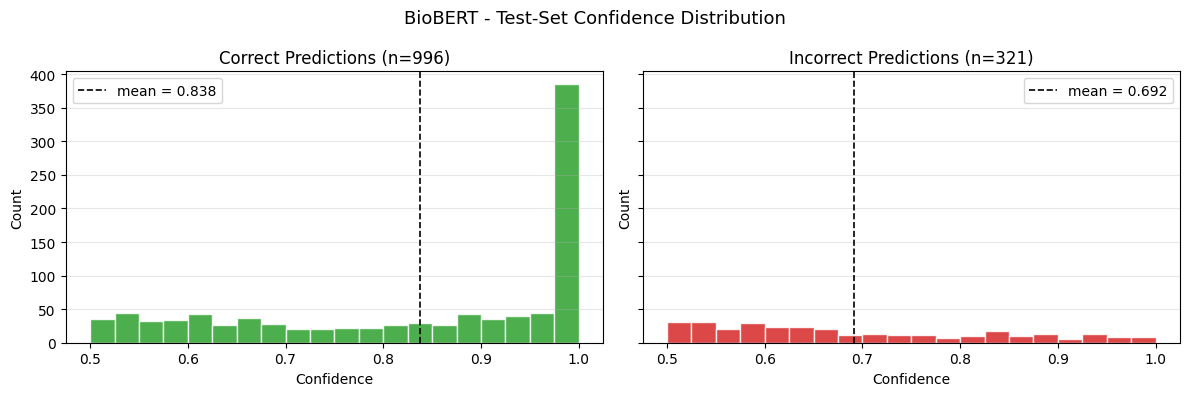

Saved confidence plot to C:\Users\ribam\Desktop\Reseach\Dataset\output\inference\biobert_confidence_distribution.png


In [22]:
import matplotlib.pyplot as plt

PRED_CSV_MAP = {
    "BioBERT": OUTPUT_ROOT / "biobert_fakehealth_healthfact" / "biobert_test_predictions.csv",
    "PubMedBERT": OUTPUT_ROOT / "pubmedbert_fakehealth_healthfact" / "pubmedbert_test_predictions.csv",
}

analysis_model = best_transformer_name if best_transformer_name in PRED_CSV_MAP else "BioBERT"
pred_csv_path = PRED_CSV_MAP[analysis_model]
pred_df = pd.read_csv(pred_csv_path)

pred_df["confidence"] = pred_df.apply(
    lambda r: r["prob_class_1"] if r["prediction"] == 1 else r["prob_class_0"],
    axis=1,
)
pred_df["correct"] = pred_df["prediction"] == pred_df["label"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, (correct, title, color) in zip(
    axes,
    [
        (True, "Correct Predictions", "#2ca02c"),
        (False, "Incorrect Predictions", "#d62728"),
    ],
):
    subset = pred_df[pred_df["correct"] == correct]["confidence"]
    ax.hist(subset, bins=20, range=(0.5, 1.0), color=color, edgecolor="white", alpha=0.85)
    ax.set_title(f"{title} (n={len(subset)})")
    ax.set_xlabel("Confidence")
    ax.set_ylabel("Count")
    if len(subset):
        ax.axvline(subset.mean(), color="black", linestyle="--", linewidth=1.2, label=f"mean = {subset.mean():.3f}")
        ax.legend()
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(f"{analysis_model} - Test-Set Confidence Distribution", fontsize=13)
plt.tight_layout()

conf_plot_path = INFER_OUT_DIR / f"{analysis_model.lower().replace(' ', '_')}_confidence_distribution.png"
plt.savefig(conf_plot_path, dpi=150)
plt.show()
print("Saved confidence plot to", conf_plot_path)


## 10. Wrong-but-Confident Cases

High-confidence mistakes are the most informative failure mode — the model is wrong AND certain about it. These are strong candidates for the qualitative discussion in the thesis.


In [23]:
CONFIDENCE_THRESHOLD = 0.80   # adjust as needed

wrong_confident = (
    pred_df[~pred_df['correct'] & (pred_df['confidence'] >= CONFIDENCE_THRESHOLD)]
    [['dataset', 'record_id', 'label', 'prediction', 'confidence', 'text']]
    .sort_values('confidence', ascending=False)
    .reset_index(drop=True)
)

print(f'Wrong but confident (≥{CONFIDENCE_THRESHOLD:.0%}) : {len(wrong_confident)} examples')
wrong_confident.head(10)

Wrong but confident (≥80%) : 86 examples


,dataset,record_id,label,prediction,confidence,text
0,healthfact,12063,0,1,0.998707,Missouri Votes to Let Employers Fire People Wh...
1,healthfact,23466,0,1,0.995479,"Alex Sink wants to ""cut Medicare."
2,healthfact,15085,0,1,0.994577,HIV/AIDS among women is skyrocketing in Austin.
3,healthfact,9895,0,1,0.990776,"For Cold Virus, Zinc May Edge Out Even Chicken..."
4,healthfact,15218,0,1,0.990335,"Planned Parenthood is ""not actually doing wome..."
5,healthfact,10025,0,1,0.987545,Aspirin Linked to Lower Pancreatic Cancer Risk
6,healthfact,12792,0,1,0.985415,"300,000 pounds of rat meat sold as chicken win..."
7,healthfact,10201,0,1,0.985309,Partial rather than full knee replacements bet...
8,healthfact,32930,0,1,0.983554,New York state has legalized heroin.
9,healthfact,10069,0,1,0.966621,Compound May Fight Hard-to-Treat Lung Cancer


In [24]:
safe_model_name = globals().get("analysis_model", globals().get("best_transformer_name", "transformer"))
safe_model_name = safe_model_name.lower().replace(" ", "_").replace("+", "plus")

wc_path = INFER_OUT_DIR / f"{safe_model_name}_wrong_confident.csv"
wrong_confident.to_csv(wc_path, index=False)
print("Saved wrong-but-confident cases to", wc_path)


Saved wrong-but-confident cases to C:\Users\ribam\Desktop\Reseach\Dataset\output\inference\biobert_wrong_confident.csv
